# 05 — Galactic noise

GRAND's sensitivity floor is not its electronics. It is the Galaxy.

Below about 300 MHz the sky is a bright radio source — thousands of kelvin of
synchrotron emission from cosmic-ray electrons in the Galactic magnetic field —
and any antenna pointed at it receives that power whether you want it or not.
Every trigger threshold, every sensitivity estimate and every detection
significance in GRAND rests on how large that floor is.

This notebook follows **one number** — the microvolts of noise on one antenna
arm — from the radio sky to a simulated trace, and then checks it. Each step
below is a real array shipped with the package, so the chain can be walked
rather than described.

The last step is worth flagging in advance. The expected noise level can be
rebuilt here, independently of the simulation code, from the tables and the
antenna impedance. It agrees to a fraction of a percent. That closes a loop
which was an open question in this repository until September 2026.

## 1. The sky

The LFMap survey gives brightness temperature over the sky as a function of
frequency. GRANDlib ships it as one array per megahertz, each unpacking into
right ascension, a polar angle, and temperature on a 72 × 36 grid.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grand import grand_add_path_data

ra, polar, temp_30 = np.load(grand_add_path_data("noise/LFmap/LFmapshort30.npy"))
temp_250 = np.load(grand_add_path_data("noise/LFmap/LFmapshort250.npy"))[2]

print("grid          ", temp_30.shape, " (72 x 36 over the sky)")
print("ra            %.2f to %.2f rad" % (ra.min(), ra.max()))
print("polar angle   %.2f to %.2f rad" % (polar.min(), polar.max()))
print()
print("T at  30 MHz  %8.0f to %8.0f K" % (temp_30.min(), temp_30.max()))
print("T at 250 MHz  %8.0f to %8.0f K" % (temp_250.min(), temp_250.max()))
print("median ratio  %8.0f" % (np.median(temp_30) / np.median(temp_250)))

ERROR in cling::CIFactory::createCI(): cannot extract standard library include paths!
Invoking:
  LC_ALL=C x86_64-conda-linux-gnu-c++  -O3 -DNDEBUG -xc++ -E -v /dev/null 2>&1 | sed -n -e '/^.include/,${' -e '/^ \/.*++/p' -e '}'
Results was:
With exit code 0
C system headers (glibc/Xcode/Windows SDK) must be installed.
In file included from input_line_4:36:
/../lib/gcc/x86_64-linux-gnu/13/../../../../include/c++/13/cassert:44:10: fatal error: 'assert.h' file not found
#include <assert.h>
         ^~~~~~~~~~


input_line_37:1:10: fatal error: 'dlfcn.h' file not found
#include "dlfcn.h"
         ^~~~~~~~~


grid           (72, 36)  (72 x 36 over the sky)
ra            0.04 to 6.24 rad
polar angle   0.04 to 3.10 rad

T at  30 MHz      6584 to   228664 K
T at 250 MHz        39 to     1849 K
median ratio       183


Two hundred thousand kelvin at the bottom of the band, two thousand at the
top. **That factor of ~180 across GRAND's own band is the single most important
fact about its noise**, and it is why every spectrum later in this notebook
falls steeply to the right.

The bright ridge in the maps below is the Galactic plane sweeping through the
field of view as the Earth turns — which is also why the noise depends on the
time of day.

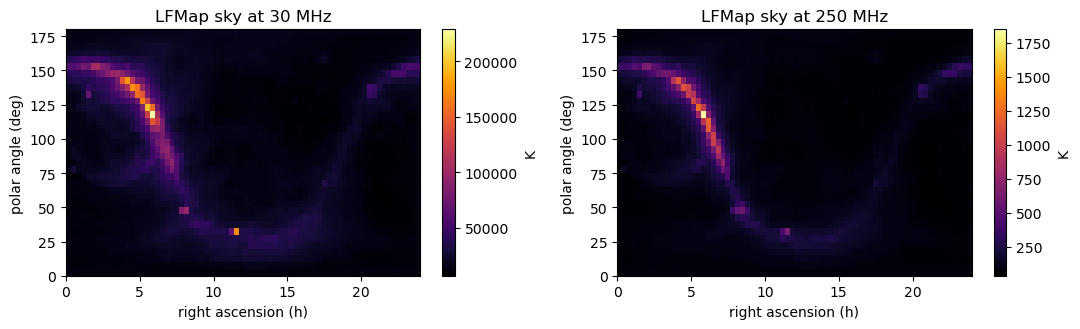

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, t, f in ((axes[0], temp_30, 30), (axes[1], temp_250, 250)):
    im = ax.imshow(t.T, origin="lower", aspect="auto", cmap="inferno",
                   extent=[0, 24, 0, 180])
    ax.set_xlabel("right ascension (h)")
    ax.set_ylabel("polar angle (deg)")
    ax.set_title("LFMap sky at %d MHz" % f)
    fig.colorbar(im, ax=ax, label="K")
fig.tight_layout()

## 2. From a hot sky to a voltage

An antenna does not measure temperature. The chain from one to the other, with
the units that matter at each step:

| step | quantity | units |
|---|---|---|
| the sky | brightness temperature $T(\alpha,\delta,\nu)$ | K |
| the antenna | effective length $\vec{h}(\theta,\phi,\nu)$ | m |
| integrate $T$ against $\lvert h_\theta\rvert^2+\lvert h_\phi\rvert^2$ | open-circuit voltage $V_{\rm oc,RMS}^2/\mathrm{Hz}$ | V²/Hz |
| divide by $4\,\mathrm{Re}(Z_{\rm ant})$ | available power $P_L$ | W/Hz |

That last division is a convention, and it is where the historical confusion in
this repository lived. Available power is what a matched load would draw; it
carries the antenna impedance with it, so a voltage can always be recovered
from it, and **the recovered voltage is an RMS by construction** — not by
choice of definition.

`Compute_Plot_Galactic_Noise.py` performs the integration and ships the result.
What GRANDlib reads at simulation time is the last row of that table.

In [3]:
du_types = ("GP300", "GP300_nec", "GP300_mat")

tables = {}
for du in du_types:
    name = "noise/galactic_PL_per_Hz_gp13_%s.npy" % du
    tables[du] = np.load(grand_add_path_data(name))

print("%-11s %-14s %s" % ("du_type", "shape", "P_L at 18 h, 50 MHz, SN arm"))
for du, table in tables.items():
    print("%-11s %-14s %.3e W/Hz" % (du, table.shape, table[20, 54, 0]))

du_type     shape          P_L at 18 h, 50 MHz, SN arm
GP300       (221, 72, 3)   6.384e-20 W/Hz
GP300_nec   (221, 72, 3)   7.102e-20 W/Hz
GP300_mat   (221, 72, 3)   7.350e-20 W/Hz


`(221, 72, 3)` — 30 to 250 MHz in 1 MHz steps, 72 sidereal-time bins at
20-minute spacing, three antenna arms.

The three models differ only in the antenna response used to produce them:
`GP300` from an HFSS simulation, `GP300_nec` from NEC, `GP300_mat` from MATLAB.
They are close but not identical, and each has its own table — worth saying,
because until September 2026 two of these files were byte-identical and the
default read neither.

## 3. The level to expect

The practical question. Integrating the table over the band gives the RMS
open-circuit voltage an antenna arm actually sees.

In [4]:
zant = np.loadtxt(grand_add_path_data("detector/RFchain_v2/Z_ant_3.2m.csv"),
                  delimiter=",", skiprows=1)
r_ant = np.column_stack([zant[:, 1], zant[:, 3], zant[:, 5]])   # Re Z, per arm
BIN_HZ = 1e6

def rms_uv(table, lst_bin):
    """Open-circuit RMS voltage per arm, in microvolts, at one LST bin."""
    variance = 4.0 * table[:, lst_bin, :] * BIN_HZ * r_ant       # V^2 per bin
    return np.sqrt(variance.sum(axis=0)) * 1e6

print("%-11s %8s %8s %8s   (uV RMS at LST 18 h)" % ("du_type", "SN", "EW", "Z"))
for du, table in tables.items():
    print("%-11s %s" % (du, "  ".join("%6.1f  " % v for v in rms_uv(table, 54))))

du_type           SN       EW        Z   (uV RMS at LST 18 h)
GP300         29.9      38.0      35.1  
GP300_nec     31.6      39.5      37.9  
GP300_mat     32.6      40.5      37.4  


Around 30 to 40 µV. That is the number to have in mind: a GRAND antenna sits
on a galactic noise floor of a few tens of microvolts, and a shower pulse has to
compete with it.

The three models agree to about 10 %, which is a fair statement of how well the
antenna response is known.

## 4. Sidereal time

The Galactic plane rises and sets, and the noise follows it. The cell below
measures how much.

quietest 24.9 uV at 6.0 h,  busiest 33.2 uV at 22.7 h,  ratio 1.33


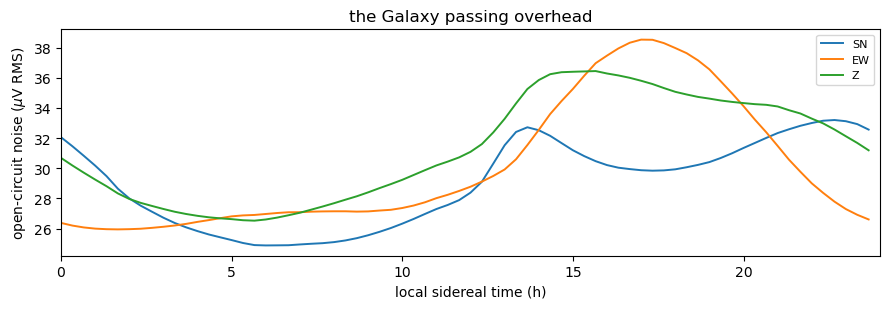

In [5]:
hours = np.arange(72) / 3.0
levels = np.array([rms_uv(tables["GP300"], b) for b in range(72)])

fig, ax = plt.subplots(figsize=(9, 3.2))
for arm, name in enumerate(("SN", "EW", "Z")):
    ax.plot(hours, levels[:, arm], lw=1.4, label=name)
ax.set_xlabel("local sidereal time (h)")
ax.set_ylabel(r"open-circuit noise ($\mu$V RMS)")
ax.set_xlim(0, 24); ax.legend(fontsize=8)
ax.set_title("the Galaxy passing overhead")
fig.tight_layout()

print("quietest %.1f uV at %.1f h,  busiest %.1f uV at %.1f h,  ratio %.2f"
      % (levels[:, 0].min(), hours[levels[:, 0].argmin()],
         levels[:, 0].max(), hours[levels[:, 0].argmax()],
         levels[:, 0].max() / levels[:, 0].min()))

About a third, between the quietest hour and the busiest — larger than the
spread between the three antenna models, and not something to average over.

**A quoted noise level without a sidereal time is incomplete.** This is not a
defect; it is the sky. But "the GRAND noise floor is X µV" is an unfinished
sentence, and comparisons between studies need to fix the hour before they mean
anything.

## 5. What the simulation returns

`galactic_noise` draws one realisation: complex Fourier coefficients whose
magnitudes follow the table and whose phases are random.

In [6]:
from grand.sim.noise.galaxy import galactic_noise

FREQS = np.arange(30.0, 251.0)
SIZE = 2048

spectrum = galactic_noise(18.0, SIZE, FREQS, nb_ant=200, seed=1,
                          du_type="GP300")
full = np.zeros((200, 3, SIZE // 2 + 1), dtype=complex)
full[:, :, 30:251] = spectrum
traces = np.fft.irfft(full, n=SIZE, axis=-1)

print("spectrum", spectrum.shape, "  traces", traces.shape)
print("trace RMS per arm: %s uV"
      % "  ".join("%.1f" % v for v in traces.std(axis=(0, 2))))

spectrum (200, 3, 221)   traces (200, 3, 2048)
trace RMS per arm: 29.8  37.9  35.3 uV


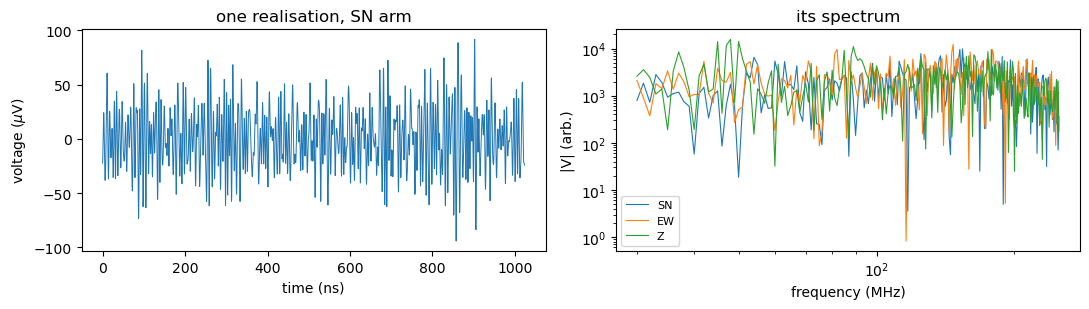

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(np.arange(SIZE) * 0.5, traces[0, 0], lw=0.7)
axes[0].set_xlabel("time (ns)"); axes[0].set_ylabel(r"voltage ($\mu$V)")
axes[0].set_title("one realisation, SN arm")

for arm, name in enumerate(("SN", "EW", "Z")):
    axes[1].loglog(FREQS, np.abs(spectrum[0, arm]), lw=0.8, label=name)
axes[1].set_xlabel("frequency (MHz)"); axes[1].set_ylabel("|V| (arb.)")
axes[1].set_title("its spectrum"); axes[1].legend(fontsize=8)
fig.tight_layout()

The spectrum falls steeply with frequency, which is the sky map from section 1
seen a different way.

Note that the *same seed gives the same noise*, which matters more than it
sounds: a simulation whose noise changes between runs cannot be compared with
itself. Notebook 08 pins exactly this.

## 6. Closing the loop

Everything above was description. This is the check.

The prediction is rebuilt here from the shipped tables and the antenna
impedance, using only the relation in section 2 — nothing from
`grand.sim.noise.galaxy`. If the simulation and the prediction agree, then the
code turns the tables into voltages the way the physics says it should.

In [8]:
predicted = rms_uv(tables["GP300"], 54)
simulated = traces.std(axis=(0, 2))

print("%-12s %8s %8s %8s" % ("", "SN", "EW", "Z"))
print("%-12s %s" % ("predicted", "  ".join("%7.2f " % v for v in predicted)))
print("%-12s %s" % ("simulated", "  ".join("%7.2f " % v for v in simulated)))
print("%-12s %s" % ("ratio", "  ".join("%7.4f " % v
                                       for v in simulated / predicted)))

                   SN       EW        Z
predicted      29.93     37.98     35.07 
simulated      29.81     37.85     35.28 
ratio         0.9961    0.9967    1.0060 


Within a few tenths of a percent, and that residual is not an error in either
side — it is the finite draw. With 200 antennas the sample RMS scatters about
its expectation by roughly

$$\frac{1}{\sqrt{2\,n_{\rm ant}N_{\rm eff}}},\qquad
  N_{\rm eff}=\frac{(\sum_k\sigma_k^2)^2}{\sum_k\sigma_k^4}$$

which is a few tenths of a percent here. `tests/sim/test_galactic_noise_normalisation.py`
makes this a test, with the tolerance derived from that expression rather than
chosen.

**This is the loop closing.** Stavros Nonis generates the tables as
$P_L = V_{\rm oc,RMS}^2/[4\,\mathrm{Re}(Z_{\rm ant})]$ from the LFMap sky; the
simulation inverts that relation; and the cell above rebuilds it a third time,
independently. Sky temperature to simulated voltage, checked at both ends.

## 7. If you hold files from before September 2026

Until 2026-09-07 the simulation scaled the spectrum by `size_out/2` rather than
`size_out/sqrt(2)`, on the unresolved assumption that the tabulated quantity
might be a maximum rather than an RMS. It is an RMS, by construction — see
section 2 — so:

> **Every simulated voltage produced before 2026-09-07 is low by $\sqrt2$.**

New files record the version that wrote them, in `TVoltage.grandlib_version`.
Files with no stamp predate the fix. Whether anything is reprocessed is an open
question for the collaboration, not a code one.

## 8. What is still not checked here

The LFMap sky model itself. Sections 3 to 6 verify that GRANDlib turns the
tables into voltages correctly; nothing in this repository re-derives the
brightness temperatures of section 1, or the antenna effective lengths they are
integrated against. Those come from outside, and are documented in
[data files](../docs/source/data_files.rst) rather than reproduced.

## Where next

- [03 — The antenna response](03_antenna_response.ipynb) — the effective length this integrates against
- [06 — From electric field to ADC](06_efield_to_adc.ipynb) — where this noise is added to a shower
- [08 — Pinning the chain](08_pipeline_regression.ipynb) — how the level is kept from drifting